In [ ]:
import copy
import os
import re
import sys
import warnings
from collections.abc import Iterable
from copy import deepcopy
from pdb import line_prefix

import joblib
import mne
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import BoundaryNorm, ListedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy import ndimage
from scipy.stats import t, ttest_rel
from scipy.ndimage import label
from nilearn import plotting, datasets, image
from nilearn.image import get_data, math_img, new_img_like, threshold_img, coord_transform, resample_to_img
from nilearn.regions import connected_regions
from pyriemann.classification import MDM
from pyriemann.clustering import Potato, PotatoField
from pyriemann.estimation import Covariances
from rsatoolbox.inference import eval_fixed
from mne.stats import permutation_cluster_1samp_test

sys.path.append('/home/reabt/experiments/ncc/MRI/code/')
from utils.load_cfg import load_fusion_config_instance, load_MEG_config_instance, load_MRI_config_instance
from utils.subj import *
from utils.fusion_stat import *

mne.viz.set_browser_backend('matplotlib')

Using matplotlib as 2D backend.


### Functions

In [2]:
times = np.array([-1.  , -0.99, -0.98, -0.97, -0.96, -0.95, -0.94, -0.93, -0.92,
       -0.91, -0.9 , -0.89, -0.88, -0.87, -0.86, -0.85, -0.84, -0.83,
       -0.82, -0.81, -0.8 , -0.79, -0.78, -0.77, -0.76, -0.75, -0.74,
       -0.73, -0.72, -0.71, -0.7 , -0.69, -0.68, -0.67, -0.66, -0.65,
       -0.64, -0.63, -0.62, -0.61, -0.6 , -0.59, -0.58, -0.57, -0.56,
       -0.55, -0.54, -0.53, -0.52, -0.51, -0.5 , -0.49, -0.48, -0.47,
       -0.46, -0.45, -0.44, -0.43, -0.42, -0.41, -0.4 , -0.39, -0.38,
       -0.37, -0.36, -0.35, -0.34, -0.33, -0.32, -0.31, -0.3 , -0.29,
       -0.28, -0.27, -0.26, -0.25, -0.24, -0.23, -0.22, -0.21, -0.2 ,
       -0.19, -0.18, -0.17, -0.16, -0.15, -0.14, -0.13, -0.12, -0.11,
       -0.1 , -0.09, -0.08, -0.07, -0.06, -0.05, -0.04, -0.03, -0.02,
       -0.01,  0.  ,  0.01,  0.02,  0.03,  0.04,  0.05,  0.06,  0.07,
        0.08,  0.09,  0.1 ,  0.11,  0.12,  0.13,  0.14,  0.15,  0.16,
        0.17,  0.18,  0.19,  0.2 ,  0.21,  0.22,  0.23,  0.24,  0.25,
        0.26,  0.27,  0.28,  0.29,  0.3 ,  0.31,  0.32,  0.33,  0.34,
        0.35,  0.36,  0.37,  0.38,  0.39,  0.4 ,  0.41,  0.42,  0.43,
        0.44,  0.45,  0.46,  0.47,  0.48,  0.49,  0.5 ,  0.51,  0.52,
        0.53,  0.54,  0.55,  0.56,  0.57,  0.58,  0.59,  0.6 ,  0.61,
        0.62,  0.63,  0.64,  0.65,  0.66,  0.67,  0.68,  0.69,  0.7 ,
        0.71,  0.72,  0.73,  0.74,  0.75,  0.76,  0.77,  0.78,  0.79,
        0.8 ,  0.81,  0.82,  0.83,  0.84,  0.85,  0.86,  0.87,  0.88,
        0.89,  0.9 ,  0.91,  0.92,  0.93,  0.94,  0.95,  0.96,  0.97,
        0.98,  0.99])

In [51]:
def mk_subplots(rows, cols, flatten=False, sz = [3, 3], **kwargs):
	fig, axes = plt.subplots(rows, cols, figsize=(cols * sz[1], rows *  sz[0]), **kwargs)
	if flatten:
		axes = axes.flatten()
	return fig, axes


def plot_meg_topo(epochs, times, ax, ch_pick = 'mag', use_average = True):

	evoked = epochs.copy().pick(ch_pick)
	if use_average:
		evoked = evoked.average() # .apply_function(np.abs)
	evoked.plot_topomap(axes=ax, 
						show=False, 
						times = times,
						colorbar = False,
						cmap = 'RdBu_r'
						# sphere='extra'
						# sphere=0.1,
	)
	

def plot_eeg_topo(epochs, times, ax, ch_pick = 'mag', use_average = True, use_abs = False):
	with warnings.catch_warnings():
		warnings.simplefilter("ignore")
		# suppress MNE logging (info, warning, etc.)
		with mne.use_log_level('ERROR'):  # only show critical errors

			evoked = epochs.copy().pick(ch_pick)

			if use_average:
				evoked = evoked.average()
			if use_abs:
				evoked = evoked.apply_function(np.abs)
			
			evoked.set_channel_types(dict(zip(evoked.ch_names, np.tile('eeg', len(evoked.ch_names)))), verbose=False)
			evoked.plot_topomap(
				times=times,
				axes=ax,
				ch_type="eeg",          # plot one sensor type only
				show=False,
				colorbar=False,
				outlines="head",        # try "head" instead of helmet-like outlines
				extrapolate="head",     # constrain interpolation to the head outline
				contours=6,
				sphere=0.17
			)


def plot_best_evoked(epochs, idx, ax, color=None, ch_type='grad', do_avg = True, use_abs = True):
	
	evoked = epochs.copy().pick(ch_type)
	
	if do_avg:
		evoked = evoked.average()
	if use_abs:
		evoked = evoked.apply_function(np.abs)

	evoked_bestCh = evoked.copy()
	evoked_bestCh.pick([evoked.ch_names[i] for i in idx])
	times = evoked_bestCh.times
	ts = evoked_bestCh.data.mean(axis=0)
	ts_std = evoked_bestCh.data.std(axis=0, ddof=1)
	ts_sem = ts_std / np.sqrt(epochs.nave) # nave = number of datasets in average

	ax.plot(times, ts, color=color)
	ax.fill_between(times, ts - ts_sem, ts + ts_sem, color=color, alpha=0.3)


def exponent_formatter_cb(cb, orientation='horizontal', fontsize = 14, labelpad = -65):
	if orientation=='horizontal': # x axis
		offset_str = cb.ax.xaxis.get_offset_text().get_text() # get current offset string (e.g. '1e−8')
		cb.ax.xaxis.get_offset_text().set_visible(False)# hide the original offset text
	elif orientation=='vertical': # y axis
		offset_str = cb.ax.yaxis.get_offset_text().get_text()
		cb.ax.yaxis.get_offset_text().set_visible(False)# hide the original offset text

	offset_str = offset_str.replace('−', '-') # normalize unicode minus → regular minus
	match = re.search(r'e(-?\d+)', offset_str) # extract exponent using regex

	exponent = match.group(1)  # e.g. '-8'

	cb.set_label(rf'$\times 10^{{{exponent}}}$ T', fontsize=fontsize, labelpad = labelpad) #loc='right') # use LaTeX formatting for better rendering

# ======================================================================================= RSA MEG

def plot_all_subj_rsa_eval(config_class_name, all_subj, suffix = ''):

	cfg = load_MEG_config_instance(config_class_name) # uses '*' if no subjectID supplied
	models = cfg.get_model_RDM()

	if config_class_name == 'MEGconfig_C':
		inDir = '/home/reabt/experiments/ncc/MEG/data/movie_RDMs/C/'
		title_spec = 'Crossnobis'
	elif config_class_name == 'MEGconfig_E':
		inDir = '/home/reabt/experiments/ncc/MEG/data/movie_RDMs/E/'
		title_spec = 'Euclidean'
	elif config_class_name == 'MEGconfig_Eb':
		inDir = '/home/reabt/experiments/ncc/MEG/data/movie_RDMs/Eb/'
		title_spec = 'Euclidean'

	inFiles = os.listdir(inDir)
	print(f'first inFile: {inFiles[0]}')
	
	results_senso = []
	results_supra = []
	
	for file in inFiles:
		if "first" not in file:
			subjectID = os.path.splitext(file)[0][-12:]
			if subjectID in all_subj: # only plot fusin subjects
				subj_data = joblib.load(os.path.join(inDir, file))
				eval_results = eval_fixed(models, subj_data, theta=None, method='corr_cov')

				results_senso = np.array(eval_results.evaluations[0,0])
				results_supra = np.array(eval_results.evaluations[0,1])
				time = np.arange(results_senso.shape[0])

				plt.figure(figsize=(4,2.5))
				plt.plot(time, results_senso, label='Sensory', color='tab:blue')
				plt.plot(time, results_supra, label='Suprasensory', color='tab:orange')

				# plt.xlabel("Time points")
				plt.ylabel("Evaluation")
				plt.title(subjectID)
				# plt.legend()
				plt.tight_layout()
				plt.show()


def plot_mean_rsa_eval(config_class_name, all_subj, time = None, suffix = '', colors = ['tab:blue', 'tab:orange'],**plt_kwargs):

	# plt_kwargs_copy = plt_kwargs.copy()
	title = plt_kwargs.pop('title', None)
	# plt_kwargs_copy.pop('title', None)

	cfg = load_MEG_config_instance(config_class_name) # uses '*' if no subjectID supplied
	models = cfg.get_model_RDM()

	if config_class_name == 'MEGconfig_C':
		inDir = '/home/reabt/experiments/ncc/MEG/data/movie_RDMs/C/'
		title_spec = 'Crossnobis'
	elif config_class_name == 'MEGconfig_Cb':
		inDir = '/home/reabt/experiments/ncc/MEG/data/movie_RDMs/Cb/'
		title_spec = 'Crossnobis'
	elif config_class_name == 'MEGconfig_E':
		inDir = '/home/reabt/experiments/ncc/MEG/data/movie_RDMs/E/'
		title_spec = 'Euclidean'
	elif config_class_name == 'MEGconfig_Eb':
		inDir = '/home/reabt/experiments/ncc/MEG/data/movie_RDMs/Eb/'
		title_spec = 'Euclidean'

	inFiles = os.listdir(inDir)
	print(f'first inFile: {inFiles[0]}')
	
	results_senso = []
	results_supra = []
	
	for file in inFiles:
		if "first" not in file:
			if os.path.splitext(file)[0][-12:] in all_subj: # only plot fusin subjects
				subj_data = joblib.load(os.path.join(inDir, file))
				eval_results = eval_fixed(models, subj_data, theta=None, method='corr_cov')

				results_senso.append(eval_results.evaluations[0,0])
				results_supra.append(eval_results.evaluations[0,1])

	# Convert lists of (200,) arrays → 2D arrays (n_subjects, n_timepoints)
	senso_arr = np.vstack(results_senso)   # shape (n_subj, 200)
	supra_arr = np.vstack(results_supra)

	# Compute mean and SEM (standard error of the mean) across subjects
	senso_mean = senso_arr.mean(axis=0)
	senso_sem  = senso_arr.std(axis=0, ddof=1) / np.sqrt(senso_arr.shape[0])

	supra_mean = supra_arr.mean(axis=0)
	supra_sem  = supra_arr.std(axis=0, ddof=1) / np.sqrt(supra_arr.shape[0])

	# X-axis (time points)
	if time is None:
		time = np.arange(senso_arr.shape[1])


	fontsize1 = 14
	fontsize2 = 13
	# Plot with shaded error bars
	plt.figure(figsize=(5,3)) #figsize=(10,5)

	plt.plot(time, senso_mean, label='sensory', color=colors[0],**plt_kwargs)
	plt.fill_between(time, senso_mean - senso_sem, senso_mean + senso_sem, 
					 color=colors[0], alpha=0.3)

	plt.plot(time, supra_mean, label='suprasensory', color=colors[1],**plt_kwargs)
	plt.axvline(time[np.argmax(supra_mean)], color=colors[1], linestyle='--', alpha=0.5)

	plt.fill_between(time, supra_mean - supra_sem, supra_mean + supra_sem, 
					 color=colors[1], alpha=0.3)
	
	# plot maxima:
	plt.axvline(time[np.argmax(senso_mean)], color=colors[0], linestyle='--', alpha=0.5, linewidth=2)
	plt.axvline(time[np.argmax(supra_mean)], color=colors[1], linestyle='--', alpha=0.5, linewidth=2)

	plt.xlabel("Time (s)", fontsize=fontsize1)
	plt.ylabel("Spearman Correlation", fontsize=fontsize1)
	plt.xticks([-1, -0.5, 0, 0.5, 1], fontsize=fontsize2)
	# plt.xlabel(fontsize=12)
	# plt.yticks([0, 0.1, 0.2], fontsize=fontsize2)
	plt.yticks(np.arange(0, np.max([np.max(senso_mean), np.max(supra_mean)]), 0.1), fontsize=fontsize2)
	
	# plt.title(f"{title_spec}: Mean evaluations over time with SEM shaded {suffix}")
	plt.legend(fontsize=fontsize2)
	plt.tight_layout()

	plt.savefig('/home/reabt/experiments/ncc/MRI/code/plots_ÖGP/RSA_MEG_transparent3.svg', transparent=True, format='svg', dpi=300, bbox_inches='tight')
	plt.savefig('/home/reabt/experiments/ncc/MRI/code/plots_ÖGP/RSA_MEG_transparent3.png', transparent=True, format='png', dpi=300, bbox_inches='tight')
	plt.savefig('/home/reabt/experiments/ncc/MRI/code/plots_ÖGP/RSA_MEG3.svg', transparent=False, format='svg', dpi=300, bbox_inches='tight')
	plt.savefig('/home/reabt/experiments/ncc/MRI/code/plots_ÖGP/RSA_MEG3.png', transparent=False, format='png', dpi=300, bbox_inches='tight')
	plt.title(title)
	plt.show()

# ======================================================================================= RSA fMRI

def find_voxels_noNan_allSubj2(data, maskFile='/home/reabt/experiments/ncc/MRI/data/sync/19910703eigl/NCC/firstLevel_sensory_M1C/mask.nii', show_plot = True):

	# mask =  np.stack([np.all(t==1, axis=-1) for t in data], axis=0)
	mask =  np.stack([np.all(np.isfinite(t), axis=-1) for t in data], axis=0)

	# sanity check: plot the mask to make sure this makes sense
	if show_plot:
		plot_img = new_img_like(maskFile, mask)
		fig = plt.figure(figsize=(12, 3))
		display = plotting.plot_stat_map(
					plot_img, 
					display_mode='z', 
					draw_cross=False, 
					figure=fig,
					# cmap='viridis',
					black_bg=False, 
					annotate=False)
		plt.show()
	return mask.astype(bool)


def get_masked_data(data, mask_1D):
	'''
	Docstring for get_masked_data
	
	:param data: list of length n_subj with arrays of shape (s1 x s2 x s3)
	:param mask_1D: 1d format of original 3d spatial mask

	NOTE: adapted this quickly from the 4d fusion stuff... 
	we also could have just used the 3d mask for masking here, 
	or added some logik to detect the input dimensions to make it more flexible...
	'''
	s_3D = data[0].shape
	# print(f'\t\t\t  - shape of 3D data (s1 x s2 x s3): {s_3D}')
	maskedData = []

	for d in data:
		subj_maskedData = d.flatten()
		subj_maskedData = subj_maskedData[mask_1D] # single subject
		maskedData.append(subj_maskedData) # all subjects
	return np.stack([d for d in maskedData]) 


def significant_clusters_to_3d(clusters, cluster_p_values, no_nan_mask, alpha=0.05, number_per_cluster = True):

	n_vox = int(no_nan_mask.sum())
	cluster_labels_1d = np.zeros(n_vox, dtype=int)

	clu_nr = 0
	for clu, p in zip(clusters, cluster_p_values):
		if p < alpha:
			clu_nr += 1
			idx = clu[0] if isinstance(clu, tuple) else clu
			if number_per_cluster:
				cluster_labels_1d[idx] = clu_nr
			else:
				cluster_labels_1d[idx] = 1

	cluster_img_3d = np.zeros(no_nan_mask.shape, dtype=int)
	cluster_img_3d[no_nan_mask] = cluster_labels_1d
	return cluster_img_3d


def find_common_centers(masks, maskFile='/home/reabt/experiments/ncc/MRI/data/sync/19910703eigl/NCC/firstLevel_sensory_M1C/mask.nii', show_plot=True):
	'''
	masks: list of length n_subjects containing 3d boolean masks.
	returns a mask that is True only for voxels that are True in ALL input masks.
	'''
	mask =  np.stack(masks,axis=0)
	print(mask.shape)
	mask = np.all(mask, axis=0) # shape should be (s1, s2, s3) again, but only True where all subjects had True

	# mask =  np.stack([np.all(np.isfinite(t), axis=-1) for t in data], axis=0)

	if show_plot:
		plot_img = new_img_like(maskFile, mask)
		fig = plt.figure(figsize=(12, 3))
		display = plotting.plot_stat_map(
					plot_img, 
					display_mode='z', 
					draw_cross=False, 
					figure=fig,
					# cmap='viridis',
					black_bg=False, 
					annotate=False)
		plt.show()
	return mask.astype(bool)

# ======================================================================================= Fusion

def get_good_clusters_filename(cfg, n_subj, model, X_def, cluster_def_method, tail, thr, meanOpt):
	thres_str = str(thr).replace('.', '_')

	file_note_clu = f'{n_subj}_subj_{model}_{X_def}_{cluster_def_method}Thres_{tail}tailed'
	file_note_good_clu = f'{n_subj}_subj_{model}_{X_def}_{cluster_def_method}Thres_{tail}tailed_thres_{thres_str}'

	if meanOpt is False:
		fileName_good_clu = cfg.get_outFile_names()['good_clusters'].replace(
			'clusters', f'clusters_{file_note_good_clu}'
		)
	else:
		fileName_good_clu = cfg.get_outFile_names()['good_clusters_mean'].replace(
			'clusters', f'clusters_{file_note_good_clu}'
		)

	return fileName_good_clu, file_note_good_clu


def get_time_indices(time_points_ms, time_array_ms):
	idx = []
	for t in time_points_ms:
		matches = np.where(time_array_ms == t)[0]
		if len(matches) == 0:
			raise ValueError(f'Time point {t} ms not found in time_array_ms.')
		idx.append(int(matches[0]))
	return idx


def add_left_side_time_label(fig, ax, text, x_shift=0.012, fontsize=12):
	bbox = ax.get_position()
	x = bbox.x0 - x_shift
	y = (bbox.y0 + bbox.y1) / 2
	fig.text(
		x, y, text,
		va='center',
		ha='right',
		rotation=90,
		fontsize=fontsize
	)


def plot_timepoints_glass_brain(
	good_clusters,
	mask_img,
	time_points_ms,
	time_array_ms,
	title='',
	out_file=None,
	display_mode='lyrz',
	cmap=None,
	threshold=0.1,
	black_bg=False,
	annotate=False,
	draw_cross=False,
	transparent=False,
):
	if cmap is None:
		cmap = ListedColormap(['#52AA4F'])

	time_idx = get_time_indices(time_points_ms, time_array_ms)
	print(time_idx)
	n_rows = len(time_points_ms)

	fig = plt.figure(figsize=(6, 2.3 * n_rows), facecolor='white')

	fig.subplots_adjust(
		left=None, 
		bottom=None, 
		right=None, 
		top=None, 
		wspace=-0.2,
		hspace=-0.1)

	axes_for_labels = []

	for row, (t_ms, t_idx) in enumerate(zip(time_points_ms, time_idx), start=1):
		ax = fig.add_subplot(n_rows, 1, row)
		
		axes_for_labels.append(ax)

		clusters_t = good_clusters[t_idx]
		cluster_img = new_img_like(mask_img, clusters_t)

		display  = plotting.plot_glass_brain(
			cluster_img,
			display_mode=display_mode,
			draw_cross=draw_cross,
			black_bg=black_bg,
			annotate=annotate,
			axes=ax,
			cmap=cmap,
			threshold=threshold,
			colorbar=False,
		)

		ax.set_title('')

	fig.suptitle(title, y=0.995, fontsize=14)
	# fig.subplots_adjust(left=0.12, right=0.98, top=0.95, bottom=0.03, hspace=-0.2, wspace = -0.2)


	for ax, t_ms in zip(axes_for_labels, time_points_ms):
		add_left_side_time_label(fig, ax, f'{t_ms} ms', x_shift=0.005, fontsize=12)

	# if out_file is not None:
	#     fig.savefig(
	#         out_file,
	#         dpi=300,
	#         bbox_inches='tight',
	#         transparent=transparent,
	#         facecolor='white' if not transparent else None,
	#     )

	return fig


# ======================================================================================= Cluster Labels


def get_good_clusters_filename(cfg, n_subj, model, X_def, cluster_def_method, tail, thr, meanOpt):
	thres_str = str(thr).replace('.', '_')

	file_note_clu = f'{n_subj}_subj_{model}_{X_def}_{cluster_def_method}Thres_{tail}tailed'
	file_note_good_clu = f'{n_subj}_subj_{model}_{X_def}_{cluster_def_method}Thres_{tail}tailed_thres_{thres_str}'

	if meanOpt is False:
		fileName_good_clu = cfg.get_outFile_names()['good_clusters'].replace(
			'clusters', f'clusters_{file_note_good_clu}'
		)
	else:
		fileName_good_clu = cfg.get_outFile_names()['good_clusters_mean'].replace(
			'clusters', f'clusters_{file_note_good_clu}'
		)

	return fileName_good_clu, file_note_good_clu

def get_time_indices(time_points_ms, time_array_ms):
	idx = []
	for t in time_points_ms:
		matches = np.where(time_array_ms == t)[0]
		if len(matches) == 0:
			raise ValueError(f'Time point {t} ms not found in time_array_ms.')
		idx.append(int(matches[0]))
	return idx

In [4]:
conditions = [
	'NT/auditory/hit',
	'NT/auditory/miss',
	'NT/somato/hit',
	'NT/somato/miss',
	'NT/visual/hit',
	'NT/visual/miss',

	'HI/auditory',
	'HI/somato',
	'HI/visual',

	'catch/auditory',
	'catch/somato',
	'catch/visual',
]

conditions2 = [[			# grouped by sensory modality
	'HI/auditory',  
	'NT/auditory/hit',
	'NT/auditory/miss',
	'catch/auditory'],
	[
	'HI/somato',     
	'NT/somato/hit',
	'NT/somato/miss',
	'catch/somato'],
	[
	'HI/visual',   
	'NT/visual/hit',
	'NT/visual/miss',
	'catch/visual'],
]

NT_conditions_old = [		# grouped by sensory modality 
	'auditory/hit',
	'auditory/miss',
	'somato/hit',
	'somato/miss',
	'visual/hit',
	'visual/miss']

NT_conditions_new = [			# grouped by sensory modality 
	'NT/auditory/hit',
	'NT/auditory/miss',  
	'NT/somato/hit',
	'NT/somato/miss',
	'NT/visual/hit',
	'NT/visual/miss']

HI_conditions = ['HI/auditory','HI/somato','HI/visual']
NT_hits = ['NT/auditory/hit','NT/somato/hit','NT/visual/hit']

titles = ['auditory', 'tactile', 'visual']

colors = dict(hit = 'darkgreen', miss = 'orange', HI = 'blue', catch = 'purple')

# 1) MEG evoked

In [9]:
inFile = '/home/reabt/experiments/ncc/MRI/code/cluster_outputs/evoked_potato_MF__ICA__filter_0_1-30__fs_100__-1.0-1.0s_potato4grad__estim_oas__thres_z3_meg-epo.pkl'
evoked_loaded = joblib.load(inFile)

Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Using a threshold of 1.693889
stat_fun(H1): min=-3.2913771650567374 max=7.715564171700583
Running initial clustering …
Found 2 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

sig. times in ['HI/auditory', 'NT/auditory/hit', 'NT/auditory/miss', 'catch/auditory']: [0.1  0.11 0.12 0.13 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23
 0.24 0.25 0.26 0.27 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37
 0.38 0.39 0.4  0.41 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51
 0.52 0.53 0.54 0.55 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65
 0.66 0.67 0.68 0.69 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78]
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Using a threshold of 1.693889
stat_fun(H1): min=-1.6792937158929317 max=8.576993213311125
Running initial clustering …
Found 9 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

sig. times in ['HI/somato', 'NT/somato/hit', 'NT/somato/miss', 'catch/somato']: [0.08 0.09 0.1  0.11 0.12 0.13 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21
 0.22 0.23 0.24 0.25 0.26 0.27 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35
 0.36 0.37 0.38 0.39 0.4  0.41 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49
 0.5  0.51 0.52 0.53 0.54 0.55 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63
 0.64 0.65 0.66 0.67 0.68 0.69 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77
 0.78 0.79 0.8  0.81 0.82 0.83 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91
 0.92 0.93]
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Using a threshold of 1.693889
stat_fun(H1): min=-2.503923451356115 max=4.292512683088589
Running initial clustering …
Found 5 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

sig. times in ['HI/visual', 'NT/visual/hit', 'NT/visual/miss', 'catch/visual']: [0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27 0.28 0.29 0.3  0.31 0.32
 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41 0.44 0.45 0.46 0.47 0.48
 0.49 0.5  0.51 0.52 0.53 0.54 0.55 0.56 0.57 0.58 0.59 0.6  0.61 0.62
 0.63 0.64 0.65 0.66 0.67 0.68 0.69 0.7  0.71 0.72 0.73 0.74 0.75 0.76]


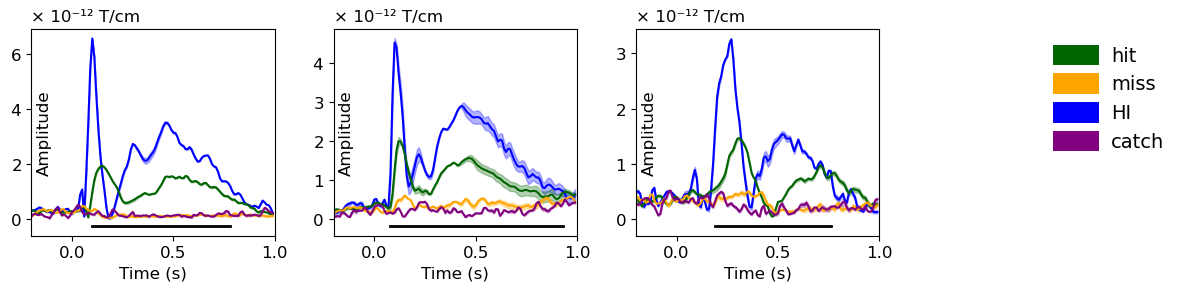

In [36]:
evoked = evoked_loaded.copy()
times = evoked[0]['HI/visual'].times

n_best = 2
ch_type = 'grad'
all_subj = os.listdir('/home/reabt/experiments/ncc/MEG/data/epochs_all_conditions/')
badSubj = []

fig, axes = mk_subplots(1, 4, False, facecolor = None)
# fig.set_facecolor(None)
fig.set_alpha(0)
for n, (modality, mod_name) in enumerate(zip(conditions2, titles)):
	ax = axes[n]
	ga_mod = mne.grand_average(
		[evo[modality[0]] for evo, subjID in zip(evoked, all_subj)
		 if (evo and subjID not in badSubj)]
	)

	evoked_mod = ga_mod.copy().pick(ch_type)
	max_activity = np.max(np.abs(evoked_mod.data), axis=1)
	bestCh_idx = np.argsort(max_activity)[-n_best:]

	for n_cond, condition in enumerate(modality):
		ga_cond = mne.grand_average(
			[evo[condition] for evo, subjID in zip(evoked, all_subj)
			 if (evo and subjID not in badSubj)]
		)

		thisColor = next((v for k, v in colors.items() if k in condition), None)

		plot_best_evoked(
			ga_cond, bestCh_idx, ax,
			color=thisColor, ch_type=ch_type,
			do_avg=False, use_abs=True
		)
			
	# --- mk data 4 statistics
	data_hit  = []
	data_miss = []

	for evo, subjID in zip(evoked, all_subj):
		if evo and subjID not in badSubj:
			hit_key = modality[1]
			miss_key = modality[2]
			ev_hit  = evo[hit_key].copy().pick(ch_type)
			ev_miss = evo[miss_key].copy().pick(ch_type)

			# same "best channels" logic as before
			hit_data  = np.mean(np.abs(ev_hit.data[bestCh_idx]), axis=0)
			miss_data = np.mean(np.abs(ev_miss.data[bestCh_idx]), axis=0)

			data_hit.append(hit_data)
			data_miss.append(miss_data)

	data_hit  = np.array(data_hit)
	data_miss = np.array(data_miss)
	
	# --- do statistics A: t-test
	# t_vals, p_vals = ttest_rel(data_hit, data_miss, axis=0)
	# sig_mask = p_vals < 0.05

	# --- do statistics B: Cluster permutation
	X = data_hit - data_miss  # paired test
	T_obs, clusters, p_values, _ = permutation_cluster_1samp_test(X, n_permutations=1000, tail=1)
	sig_mask = np.zeros(len(times), dtype=bool)
	sig_mask[np.concatenate([clu[0] for clu, p in zip(clusters, p_values) if p < 0.05])] = True

	ymin, ymax = ax.get_ylim()
	y_sig = ymin + 0.01 * (ymax - ymin)
	print(f'sig. times in {modality}: {times[sig_mask]}')
	ax.plot(times[sig_mask],
			np.full(np.sum(sig_mask), y_sig),
			color='black', linewidth=2)

	# --- rest of the plot style stuff
	# ax.set_title(mod_name)
	ax.set_xlabel('Time (s)')
	ax.set_ylabel('Amplitude', labelpad=-30) #, fontsize=14)
	ax.set_xlim(-0.2, 1)
	ax.set_xticks([0, 0.5, 1])
	ax.set_facecolor('white') 
	# ax.set

	# scientific notation for ticks
	formatter = mticker.ScalarFormatter(useMathText=True)
	formatter.set_scientific(True)
	formatter.set_powerlimits((0, 0))
	ax.yaxis.set_major_formatter(formatter)
	ax.yaxis.get_offset_text().set_visible(False) # hide the automatically generated offset text
	ax.text(0.0, 1.02, '× 10⁻¹² T/cm', transform=ax.transAxes, ha='left', va='bottom', fontsize = 12) # add your own custom scaling/unit text

legend_handles = [mpatches.Patch(color=c, label=k, linewidth=5) for i, (k, c) in enumerate(colors.items())]
# legend_handles.append = mpatches.Patch(color='k', label='p<.0.05', linewidth=0.5) 
axes[3].axis('off')
axes[3].legend(handles=legend_handles, 
			#    title='Condition',
			facecolor=None, fancybox=True, framealpha=0, fontsize = 14)

scale = 1.2
plt.tight_layout()
for ax in axes[0:3]:
	ax.title.set_fontsize(12) #(ax.title.get_fontsize() * scale)
	ax.xaxis.label.set_size(12) #(ax.xaxis.label.get_size() * scale)
	ax.yaxis.label.set_size(12) #(ax.yaxis.label.get_size() * scale)

	for label in ax.get_xticklabels() + ax.get_yticklabels():
		label.set_fontsize(12) #(label.get_fontsize() * scale)
# fig.set_facecolor(None)
# fig.savefig('/home/reabt/experiments/ncc/MRI/code/plots_ÖGP/evoked_meg_transparent2.svg', transparent=True, format='svg', dpi=300, bbox_inches='tight')
# fig.savefig('/home/reabt/experiments/ncc/MRI/code/plots_ÖGP/evoked_meg_transparent2.png', transparent=True, format='png', dpi=300, bbox_inches='tight')
# fig.savefig('/home/reabt/experiments/ncc/MRI/code/plots_ÖGP/evoked_meg2.svg', transparent=False, format='svg', dpi=300, bbox_inches='tight')
# fig.savefig('/home/reabt/experiments/ncc/MRI/code/plots_ÖGP/evoked_meg2.png', transparent=False, format='png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### evoked Topo plots

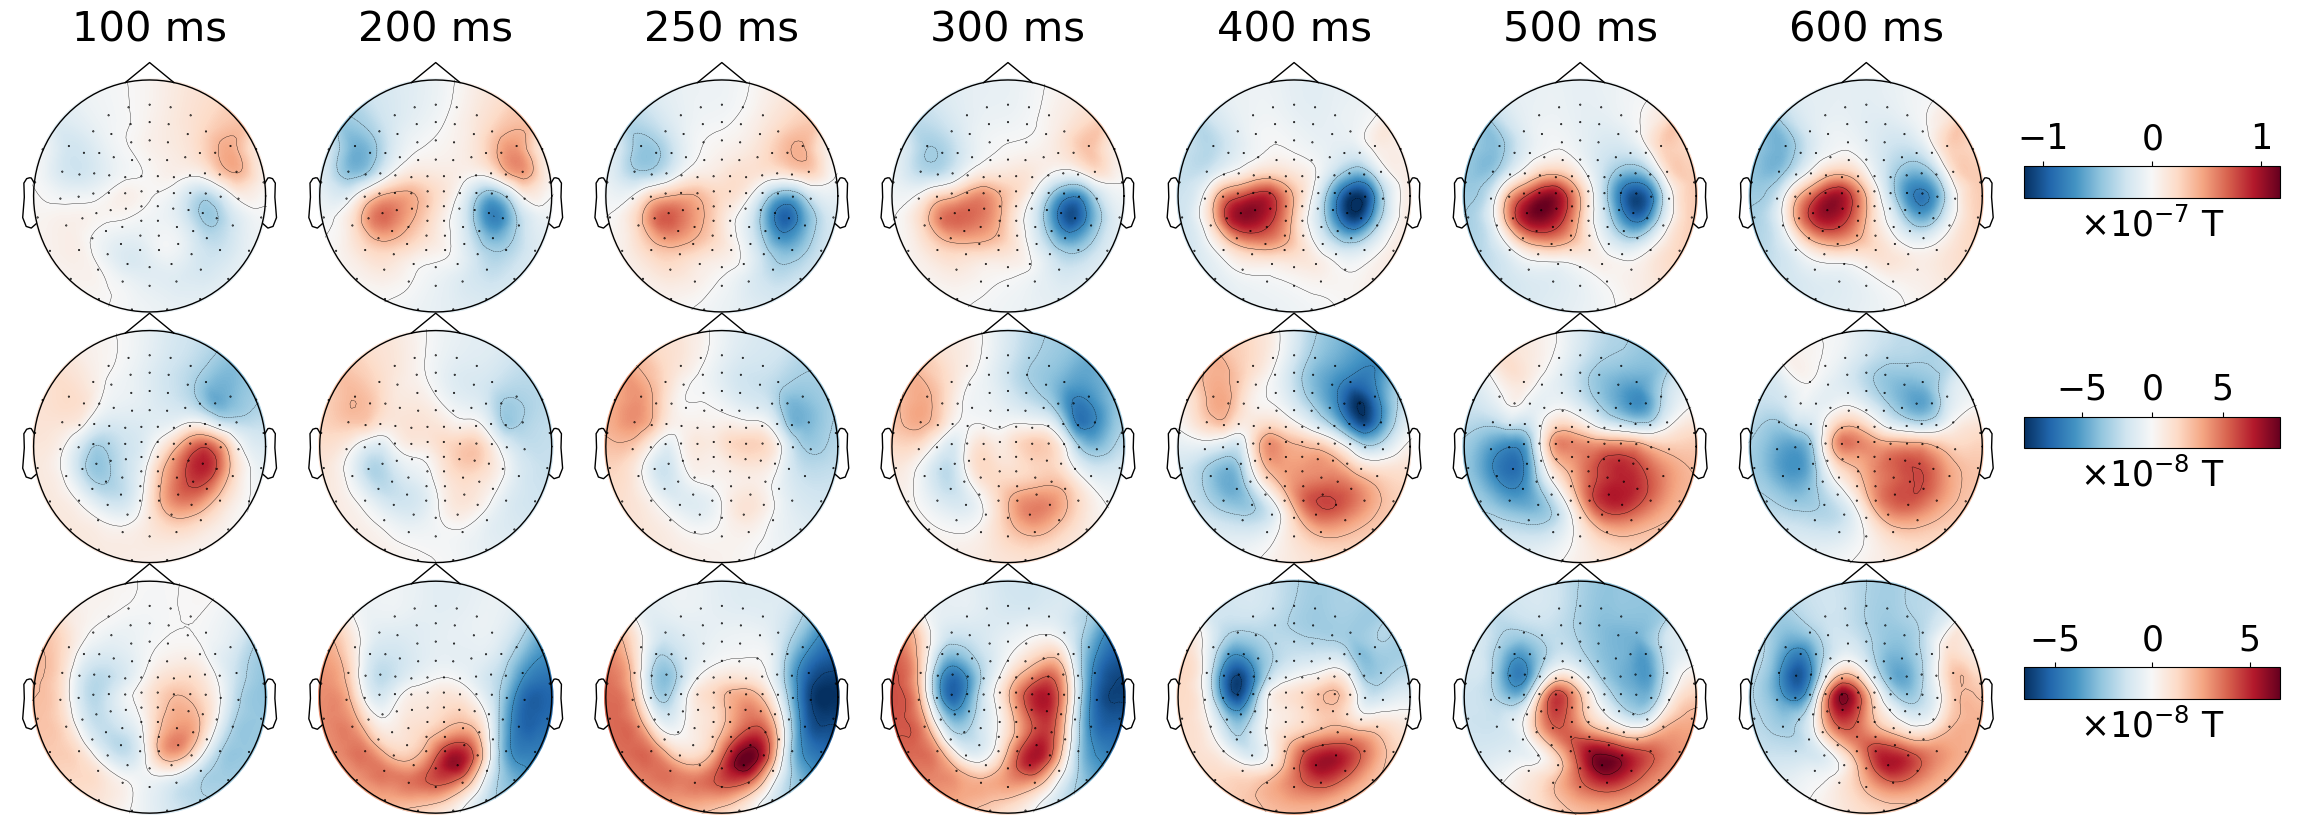

In [426]:

evoked = deepcopy(evoked_loaded)
all_subj = os.listdir('/home/reabt/experiments/ncc/MEG/data/epochs_all_conditions/')
times = [0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6]
ch_type = 'mag'

# für colorbar:
orientation = 'horizontal' 
			# orientation = 'vertical'
fontsize = 25

with warnings.catch_warnings():
	warnings.simplefilter("ignore")
	with mne.use_log_level('ERROR'):
		fig, axes = mk_subplots(3, len(times) + 1, False)

		for n, condition in enumerate(NT_hits):
			ga_cond = mne.grand_average(
				[evo[condition].copy() for evo, subjID in zip(evoked, all_subj)
				 if (evo and subjID not in badSubj)]
			)

			topo_axes = axes[n, :len(times)]
			cbar_ax = axes[n, len(times)]

			evoked4plt = ga_cond.copy().pick(ch_type)
			evoked4plt.set_channel_types(
				dict(zip(evoked4plt.ch_names, np.tile('eeg', len(evoked4plt.ch_names)))),
				verbose=False
			)

			evoked4plt.plot_topomap(
				times=times,
				axes=topo_axes,
				ch_type="eeg",
				show=False,
				colorbar=False,
				outlines="head",
				extrapolate="head",
				contours=6,
				sphere=0.17
			)

			# get one mappable from THIS row
			row_mappable = None
			for a in topo_axes:
				if len(a.images) > 0:
					row_mappable = a.images[0]
					break
				elif len(a.collections) > 0:
					row_mappable = a.collections[0]
					break

			# ~~~~~ COLORBAR				
			# create colorbar inside the 8th subplot axis
			cbar_ax = axes[n, len(times)]
			cbar_ax.set_axis_off()

			if orientation == 'horizontal':
				inset_axes_kwargs = dict(
					width="85%",    # width relative to the 8th subplot axis
					height="12%",   # height relative to the 8th subplot axis
					loc="center")
			elif orientation == 'vertical':
				inset_axes_kwargs = dict(width="12%", height="80%", loc="center left")
			
			inner_cax = inset_axes(cbar_ax, **inset_axes_kwargs)
			
			cb = fig.colorbar(row_mappable, cax=inner_cax, orientation=orientation, ticklocation='top')
			cb.ax.tick_params(labelsize=fontsize)

			fig.canvas.draw() # sonst haben wir den Text vom offset noch nicht, weil er oft erst am schluss generiert wird

			exponent_formatter_cb(cb, 
						 orientation=orientation, 
						 fontsize = fontsize, 
						 labelpad = -82)

			# ~~~~~ TITLES
			if n == 0:
				for a in topo_axes:
					a.set_title(f"{a.get_title().strip('0.').strip(' s')} ms", fontsize=30)
			else:
				for a in topo_axes:
					a.title.set_visible(False)

		plt.subplots_adjust(
			left=0.02,
			right=0.98,
			top=0.95,
			bottom=0.10,
			wspace=-0.05,
			hspace=-0.05
		)
		
		fig.savefig('/home/reabt/experiments/ncc/MRI/code/plots_ÖGP/evoked_topo_transparent3.svg', transparent=True, format='svg', dpi=300, bbox_inches='tight')
		fig.savefig('/home/reabt/experiments/ncc/MRI/code/plots_ÖGP/evoked_topo_transparent3.png', transparent=True, format='png', dpi=300, bbox_inches='tight')
		fig.savefig('/home/reabt/experiments/ncc/MRI/code/plots_ÖGP/evoked_topo3.svg', transparent=False, format='svg', dpi=300, bbox_inches='tight')
		fig.savefig('/home/reabt/experiments/ncc/MRI/code/plots_ÖGP/evoked_topo3.png', transparent=False, format='png', dpi=300, bbox_inches='tight')

		plt.show()


# 2) RSA MEG

#### Euclidean

Removed bad subject: 19970218crpo
Removed bad subject: 19950816mrse
Removed bad subject: 20050615buea
Removed bad subject: ['pilot01', 'pilot02', 'pilot03', 'old_name_19930306sbpe']
first inFile: E_rdm_movie_19930306sbeh.pkl


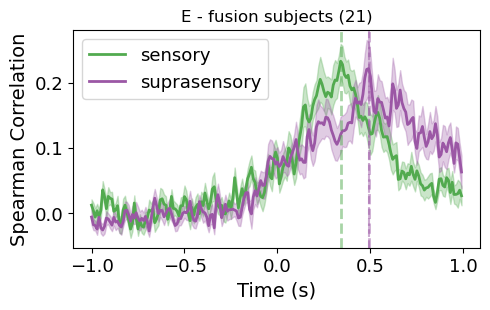

In [52]:
all_subj = get_fusion_subjects(do_print=False)
config_class_name = 'MEGconfig_E'
plot_mean_rsa_eval(config_class_name, all_subj, time=times, colors = ['#52AA4F', '#9B57A5'], lw=2, title = f'E - fusion subjects ({len(all_subj)})')

Removed bad subject: 19970218crpo
Removed bad subject: 19950816mrse
Removed bad subject: 20050615buea
Removed bad subject: ['pilot01', 'pilot02', 'pilot03', 'old_name_19930306sbpe']
first inFile: Eb_rdm_movie_19970605btre.pkl


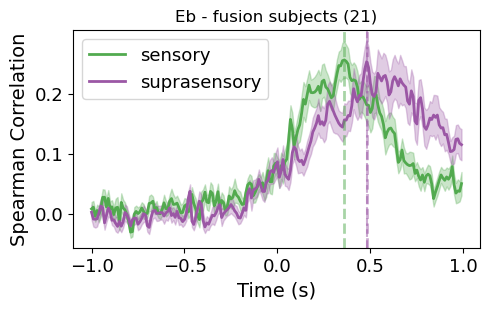

"\n#~~~ if we wanted to plot all subjects individually\nall_subj = get_fusion_subjects()\nconfig_class_name = 'MEGconfig_Eb'\nplot_all_subj_rsa_eval(config_class_name, all_subj)\n"

In [53]:
all_subj = get_fusion_subjects(do_print=False)
config_class_name = 'MEGconfig_Eb'
plot_mean_rsa_eval(config_class_name, all_subj, time=times, colors = ['#52AA4F', '#9B57A5'], lw=2, title = f'Eb - fusion subjects ({len(all_subj)})')
'''
#~~~ if we wanted to plot all subjects individually
all_subj = get_fusion_subjects()
config_class_name = 'MEGconfig_Eb'
plot_all_subj_rsa_eval(config_class_name, all_subj)
'''

Removed bad subject: 20050615buea
Removed bad subject: ['19910823ssld__maxfilter_True__ica_True__l_pass_None__downsample_f_100__h_pass_1_event_counts.pkl']
first inFile: Eb_rdm_movie_19970605btre.pkl


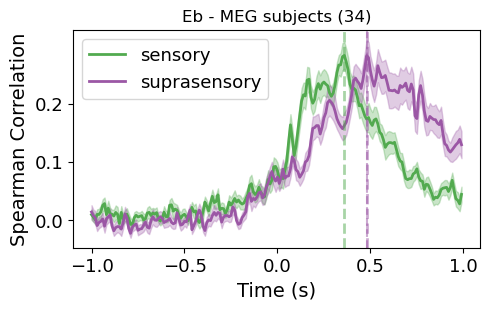

In [54]:
all_subj = get_MEG_subjects(do_print=False)
config_class_name = 'MEGconfig_Eb'
plot_mean_rsa_eval(config_class_name, all_subj, time=times, colors = ['#52AA4F', '#9B57A5'], lw=2, title = f'Eb - MEG subjects ({len(all_subj)})')

#### Crossnobis

Removed bad subject: 20050615buea
Removed bad subject: ['19910823ssld__maxfilter_True__ica_True__l_pass_None__downsample_f_100__h_pass_1_event_counts.pkl']
first inFile: C_rdm_movie_cv_run_idx_19990810mrkh.pkl


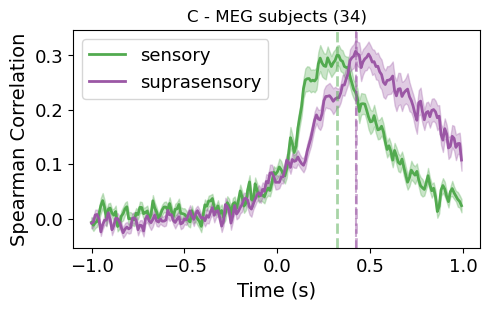

In [55]:
all_subj = get_MEG_subjects(do_print=False)
config_class_name = 'MEGconfig_C'
plot_mean_rsa_eval(config_class_name, all_subj, time=times, colors = ['#52AA4F', '#9B57A5'], lw=2, title = f'C - MEG subjects ({len(all_subj)})')

Removed bad subject: 20050615buea
Removed bad subject: ['19910823ssld__maxfilter_True__ica_True__l_pass_None__downsample_f_100__h_pass_1_event_counts.pkl']
first inFile: Cb_rdm_movie_cv_run_idx_19920917gbse.pkl


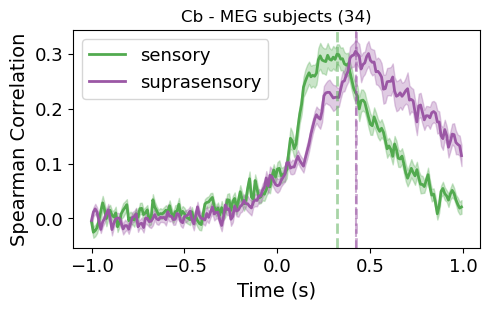

In [56]:
all_subj = get_MEG_subjects(do_print=False)
config_class_name = 'MEGconfig_Cb'
plot_mean_rsa_eval(config_class_name, all_subj, time=times, colors = ['#52AA4F', '#9B57A5'], lw=2, title = f'Cb - MEG subjects ({len(all_subj)})')

# 3) RSA fMRI

In [ ]:
# E5_centers_mask = deepcopy(centers_masks)
# C2_centers_mask = deepcopy(centers_masks)

# centers_masks = deepcopy(C2_centers_mask)
# common_centers_mask = find_common_centers(centers_masks, mask, show_plot=False)
# mask_1d = common_centers_mask.flatten()

(23, 63, 76, 55)


### get the data

In [9]:
all_subjects =get_MRI_subjects()
config_class_name = 'MRIconfig_C2'

allModels = ALL_MODELS

# for model in allModels:
model = allModels[1]

RDM_brain_list = []
centers_masks = []
for subjectID in all_subjects:
	# print(subjectID)
	cfg = load_MRI_config_instance(config_class_name, subjectID)
	cfg.modelType = model  
	outFiles = cfg.get_outFile_names()

	# centers_masks.append(cfg.get_centers_mask())
	if os.path.isdir(outFiles['RDM_brain_fullBrain']):
		RDM_brain = joblib.load(outFiles['RDM_brain_fullBrain'])
		mask =nib.load(cfg.get_mask_file())
		RDM_brain_list.append(RDM_brain)

common_centers_mask = find_common_centers(centers_masks, mask, show_plot=False)
mask_1d = common_centers_mask.flatten()


Removed bad subject: 19970218crpo
Removed bad subject: 19950816mrse
Removed bad subject: 20050615buea
Removed bad subject: ['pilot01', 'pilot02', 'pilot03', 'old_name_19930306sbpe']

all MRI subjects: ['19951227eipo', '19970302urmr', '19910823ssld', '20020705ttbr', '19991211mrbn', '19910703eigl', '20020123sbhp', '19960630cahi', '20010917rswg', '19921205crfi', '19880331igse', '19840930bigs', '19961123crsh', '20040627vrrj', '19970520smsr', '20000118sbnb', '20040630gbaf', '20070324hlti', '19960628gblm', '20050204vrao', '20050610atbu', '19930306sbeh', '20021027sldn', '19970801cabd']


ValueError: need at least one array to stack

### do the cluster permutation

In [63]:

X = get_masked_data(RDM_brain_list, mask_1d)

# # adjacency for those same voxels
adjacency = get_spatial_adjacency_3d(common_centers_mask) # needs to be the mask that we used for masking the voxel data

# cluster-forming threshold
n_subj = X.shape[0]

tail = 1
p_thres = 0.000001

if tail == 0:
	threshold = t.ppf(1 - p_thres / 2, df=n_subj - 1)
if tail == 1:
	threshold = t.ppf(1 - p_thres, df=n_subj - 1)

T_obs, clusters, cluster_p_values, H0 = permutation_cluster_1samp_test(
    X,
    threshold=threshold,
    n_permutations=5000,
    tail=tail,
    adjacency=adjacency,
    out_type='indices',
    seed=42,
    verbose=True
)

		 - Getting adjacency

 inside "_permutation_cluster_test" function:
 n_tests=62834, n_times=62834
stat_fun(H1): min=-3.7822931101826947 max=15.919562823285464
Running initial clustering …


Found 49 clusters


  0%|          | Permuting : 0/4999 [00:00<?,       ?it/s]

/tmp/ipykernel_2579582/4132272634.py:8: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  cluster_img = new_img_like(cfg.get_mask_file(), cluster_img_3d)


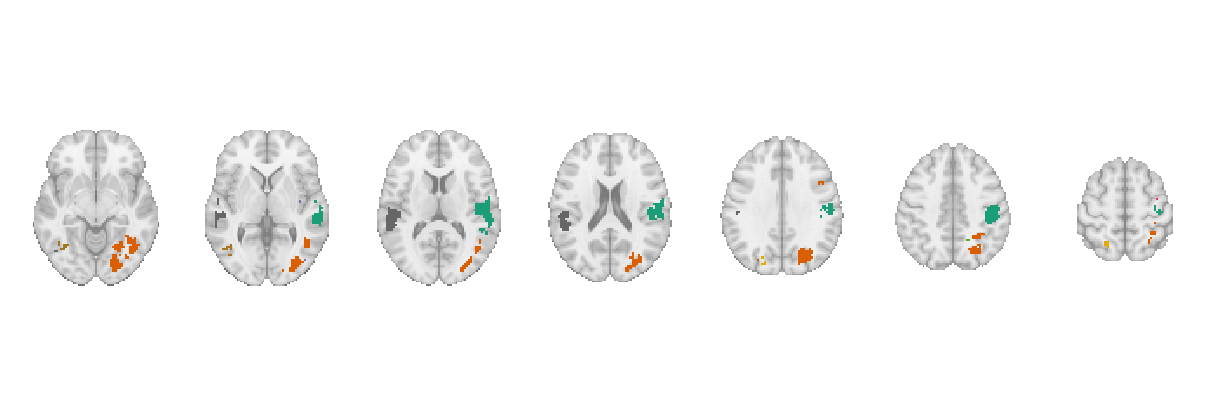

/tmp/ipykernel_2579582/4132272634.py:26: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  cluster_img = new_img_like(cfg.get_mask_file(), cluster_img_3d)


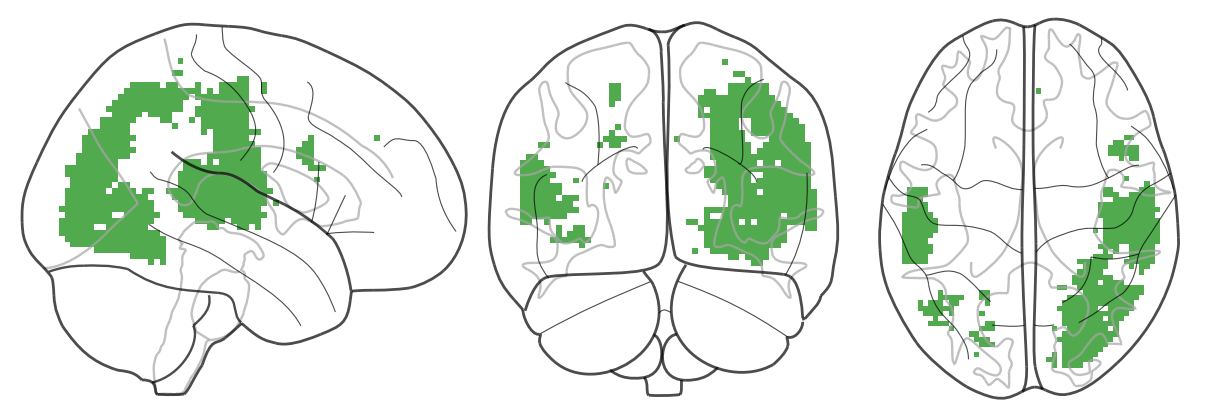

In [ ]:

mycolor =  ['#52AA4F', '#9B57A5']
# cmap = ListedColormap(['#9B57A5'])
cmap = ListedColormap(['#52AA4F'])

cluster_img_3d = significant_clusters_to_3d(clusters, cluster_p_values, common_centers_mask, alpha=0.05)
cluster_img = new_img_like(cfg.get_mask_file(), cluster_img_3d)


fig = plt.figure(figsize=(12, 4))
plotting.plot_stat_map(
    cluster_img,
    display_mode='z',
    draw_cross=False,
    black_bg=False,
    annotate=False,
    figure=fig,
	colorbar=False,
	cmap='Dark2'
)

plt.show()

cluster_img_3d = significant_clusters_to_3d(clusters, cluster_p_values, common_centers_mask, alpha=0.05, number_per_cluster=True)
cluster_img = new_img_like(cfg.get_mask_file(), cluster_img_3d)

fig = plt.figure(figsize=(12, 4))
plotting.plot_glass_brain(
    cluster_img,
    draw_cross=False,
	threshold=0.5, # only show voxels with cluster label > 0
    black_bg=False,
    annotate=False,
    figure=fig,
	colorbar=False,
	cmap=cmap,
)
#  ['#52AA4F', '#9B57A5']
# fig.savefig('/home/reabt/experiments/ncc/MRI/code/plots_ÖGP/RSA_fMRI_sensory_transparent.svg', transparent=True, format='svg', dpi=300, bbox_inches='tight')
# fig.savefig('/home/reabt/experiments/ncc/MRI/code/plots_ÖGP/RSA_fMRI_sensory_transparent.png', transparent=True, format='png', dpi=300, bbox_inches='tight')
# fig.savefig('/home/reabt/experiments/ncc/MRI/code/plots_ÖGP/RSA_fMRI_sensory.svg', transparent=False, format='svg', dpi=300, bbox_inches='tight')
# fig.savefig('/home/reabt/experiments/ncc/MRI/code/plots_ÖGP/RSA_fMRI_sensory.png', transparent=False, format='png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

/tmp/ipykernel_2579582/3356481262.py:2: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  cluster_img = new_img_like(cfg.get_mask_file(), cluster_img_3d)


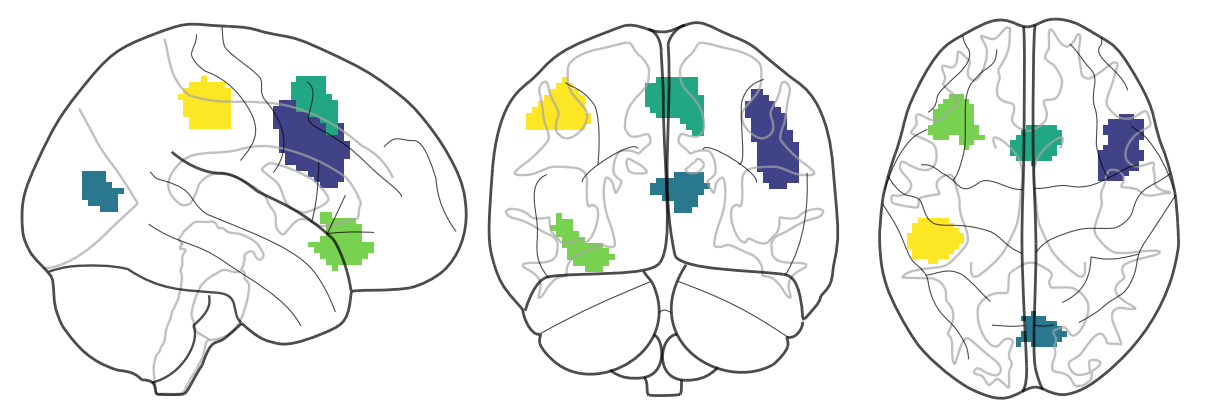

In [29]:
cluster_img_3d = significant_clusters_to_3d(clusters, cluster_p_values, common_centers_mask, alpha=0.05, number_per_cluster=True)
cluster_img = new_img_like(cfg.get_mask_file(), cluster_img_3d)

fig = plt.figure(figsize=(12, 4))
plotting.plot_glass_brain(
    cluster_img,
    draw_cross=False,
	threshold=0.5, # only show voxels with cluster label > 0
    black_bg=False,
    annotate=False,
    figure=fig,
	colorbar=False,
	cmap='viridis',
)
plt.show()


# Fusion

In [ ]:
all_configs = [
	"FusionConfig_E2",
	"FusionConfig_E5",
	"FusionConfig_C2",
	"FusionConfig_C5",
	"FusionConfig_E2_10trl",
	"FusionConfig_E5_10trl",
	"FusionConfig_C2_10trl",
	"FusionConfig_C5_10trl",
]

config_class_names = [all_configs[c] for c in [6, 7]]
# config_class_names = all_configs[6]
meanMEG = [False]
thres = [0.05]
n_subj = 18
models = ALL_MODELS
tail = 1
cluster_def_method = 'p'
# cp_variables = ['X_pre', 'X_post']
cp_variables = ['X_post']

subjectID = '19910823ssld'
# time_points_ms = [200, 300, 400, 500, 600]
# time_points_ms = [170, 220, 270, 320, 370, 400]
time_points_ms = [170, 220, 270, 400, 370, 320]
time_array = np.arange(0, 1000, 10)

outdir = '/home/reabt/experiments/ncc/MRI/code/cluster_outputs_static_glass'
os.makedirs(outdir, exist_ok=True)

cmaps = dict(
	sensory = ListedColormap(['#52AA4F']), 
	suprasensory = ListedColormap(['#9B57A5']))

display_mode = 'ortho'
plot_threshold = 0.1
black_bg = False
annotate = False
draw_cross = False
save_transparent = False

# for thisConfig in config_class_names:
thisConfig = all_configs[3]
print(f"\nProcessing config {thisConfig}\n")

for meanOpt in meanMEG:
	for thr in thres:
		for model in models:
			cmap = cmaps[model]
			for X_def in cp_variables:
				cfg = load_fusion_config_instance(thisConfig, subjectID)
				cfg.modelType = model

				fileName_good_clu, file_note_good_clu = get_good_clusters_filename(
					cfg=cfg,
					n_subj=n_subj,
					model=model,
					X_def=X_def,
					cluster_def_method=cluster_def_method,
					tail=tail,
					thr=thr,
					meanOpt=meanOpt,
				)

				if not os.path.exists(fileName_good_clu):
					print(f"Skipping missing file: {fileName_good_clu}")
					continue

				print(f"Loading: {fileName_good_clu}")
				good_clusters = joblib.load(fileName_good_clu)

				if good_clusters.ndim != 4:
					raise ValueError(
						f'Expected good_clusters to be 4D with shape (time, x, y, z), '
						f'but got shape {good_clusters.shape}'
					)

				if good_clusters.shape[0] != len(time_array):
					print(
						f'Warning: good_clusters.shape[0] = {good_clusters.shape[0]}, '
						f'but len(time_array) = {len(time_array)}'
					)

				mask_img = nib.load(cfg.maskFile)

				cfg_suffix = thisConfig.split('_', 1)[1]
				mean_suffix = '_mean' if meanOpt else ''
				base_name = f'glass_{cfg_suffix}_{file_note_good_clu}{mean_suffix}_selected_times'

				out_png = os.path.join(outdir, f'{base_name}.png')
				out_svg = os.path.join(outdir, f'{base_name}.svg')

				title = f'{cfg_suffix} | {model} | {X_def} | p={thr}'

				fig = plot_timepoints_glass_brain(
					good_clusters=good_clusters,
					mask_img=mask_img,
					time_points_ms=time_points_ms,
					time_array_ms=time_array,
					title=title,
					out_file=out_png,
					display_mode=display_mode,
					cmap=cmap,
					threshold=plot_threshold,
					black_bg=black_bg,
					annotate=annotate,
					draw_cross=draw_cross,
					transparent=save_transparent,
				)
				fig.tight_layout()

				# fig.savefig(f'/home/reabt/experiments/ncc/MRI/code/plots_ÖGP/fusion2_{model}_transparent.svg', transparent=True, format='svg', dpi=300, bbox_inches='tight')
				# fig.savefig(f'/home/reabt/experiments/ncc/MRI/code/plots_ÖGP/fusion2_{model}_transparent.png', transparent=True, format='png', dpi=300, bbox_inches='tight')
				# fig.savefig(f'/home/reabt/experiments/ncc/MRI/code/plots_ÖGP/fusion2_{model}.svg', transparent=False, format='svg', dpi=300, bbox_inches='tight')
				# fig.savefig(f'/home/reabt/experiments/ncc/MRI/code/plots_ÖGP/fusion2_{model}.png', transparent=False, format='png', dpi=300, bbox_inches='tight', facecolor='white')
				fig.show()
				plt.close(fig)

# Cluster labels

In [ ]:
models = ALL_MODELS
time_points_ms = [170, 220, 270, 320, 370, 400]
time_array_ms = np.arange(0, 1000, 10)

time_idx = get_time_indices(time_points_ms, time_array_ms)

In [31]:
model = models[0]
thisConfig = "FusionConfig_C5"
X_def = 'X_post'
cluster_def_method = 'p'
subjectID = '19910823ssld'
cfg = load_fusion_config_instance(thisConfig, subjectID)
cfg.modelType = model

fileName_good_clu, file_note_good_clu = get_good_clusters_filename(
	cfg=cfg,
	n_subj=18,
	model=model,
	X_def=X_def,
	cluster_def_method=cluster_def_method,
	tail=1,
	thr=0.05,
	meanOpt=False,
)

good_clusters = joblib.load(fileName_good_clu)
mask_img = nib.load(cfg.maskFile)


In [32]:
print(model)
for row, (t_ms, t_idx) in enumerate(zip(time_points_ms, time_idx), start=1):
	print(f't_ms: {t_ms}')
	clusters_t = good_clusters[t_idx]
	cluster_img = new_img_like(mask_img, clusters_t)
	# print(cluster_img)
	# cluster_img: 3D nifti image with your clusters
	# nonzero voxels = significant cluster voxels

	data = cluster_img.get_fdata()

	# define connected components
	labels, n_clusters = ndimage.label(data != 0)

	rows = []

	for cluster_id in range(1, n_clusters + 1):
		cluster_mask = labels == cluster_id
		coords_vox = np.array(np.where(cluster_mask)).T
		vals = data[cluster_mask]

		# representative voxel = peak absolute value within cluster
		peak_idx = np.argmax(np.abs(vals))
		i, j, k = coords_vox[peak_idx]

		# voxel indices -> MNI coordinates
		x, y, z = coord_transform(i, j, k, cluster_img.affine)

		rows.append({
			"cluster_id": cluster_id,
			"n_voxels": int(cluster_mask.sum()),
			"peak_value": float(vals[peak_idx]),
			"x_mni": float(x),
			"y_mni": float(y),
			"z_mni": float(z),
		})

	df = pd.DataFrame(rows)# .sort_values("n_voxels", ascending=False)
	print(df.to_string(index=False))

sensory
t_ms: 170
 cluster_id  n_voxels  peak_value  x_mni  y_mni  z_mni
          1        56         1.0   53.0   -9.5   17.5
          2         1         1.0   50.5  -29.5   27.5
          3         1         1.0   50.5  -24.5   20.0
t_ms: 220
Empty DataFrame
Columns: []
Index: []
t_ms: 270
 cluster_id  n_voxels  peak_value  x_mni  y_mni  z_mni
          1         5         1.0   53.0  -37.0   22.5
          2         3         1.0   50.5  -12.0    5.0
          3        44         1.0   48.0  -52.0    2.5
          4       221         1.0   38.0  -49.5   45.0
t_ms: 320
 cluster_id  n_voxels  peak_value  x_mni  y_mni  z_mni
          1         1         1.0   38.0  -67.0    0.0
          2        18         1.0   38.0  -64.5   -2.5
          3         4         1.0   28.0  -74.5    0.0
          4         9         1.0   23.0  -74.5    0.0
t_ms: 370
 cluster_id  n_voxels  peak_value  x_mni  y_mni  z_mni
          1        23         1.0   45.5  -57.0   -2.5
          2         1   

In [33]:
print(model)

for row, (t_ms, t_idx) in enumerate(zip(time_points_ms, time_idx), start=1):
	print(f't_ms: {t_ms}')
	clusters_t = good_clusters[t_idx]
	cluster_img = new_img_like(mask_img, clusters_t)

	data = cluster_img.get_fdata()
	labels, n_clusters = ndimage.label(data != 0)

	rows = []

	for cluster_id in range(1, n_clusters + 1):
		cluster_mask = labels == cluster_id
		com = ndimage.center_of_mass(cluster_mask.astype(float))
		i, j, k = [int(round(v)) for v in com]

		x, y, z = coord_transform(i, j, k, cluster_img.affine)

		rows.append({
			"cluster_id": cluster_id,
			"n_voxels": int(cluster_mask.sum()),
			"x_mni": float(x),
			"y_mni": float(y),
			"z_mni": float(z),
		})

	df = pd.DataFrame(rows)#.sort_values("n_voxels", ascending=False)
	print(df.to_string(index=False))

sensory
t_ms: 170
 cluster_id  n_voxels  x_mni  y_mni  z_mni
          1        56   48.0  -12.0   12.5
          2         1   50.5  -29.5   27.5
          3         1   50.5  -24.5   20.0
t_ms: 220
Empty DataFrame
Columns: []
Index: []
t_ms: 270
 cluster_id  n_voxels  x_mni  y_mni  z_mni
          1         5   53.0  -32.0   22.5
          2         3   50.5  -12.0    7.5
          3        44   43.0  -52.0    0.0
          4       221   23.0  -49.5   47.5
t_ms: 320
 cluster_id  n_voxels  x_mni  y_mni  z_mni
          1         1   38.0  -67.0    0.0
          2        18   33.0  -64.5   -2.5
          3         4   28.0  -74.5    2.5
          4         9   23.0  -72.0    0.0
t_ms: 370
 cluster_id  n_voxels  x_mni  y_mni  z_mni
          1        23   43.0  -54.5    2.5
          2         1   40.5  -64.5    0.0
          3         1   40.5  -62.0   -2.5
          4         1   38.0  -64.5   -2.5
          5         2   38.0  -62.0   -5.0
t_ms: 400
 cluster_id  n_voxels  x_mni  y_mn